In [ ]:
import torch
from PIL import Image
import requests
import torch
from torchvision import io
from typing import Dict
from transformers import Qwen2VLForConditionalGeneration, AutoTokenizer, AutoProcessor

In [2]:
# Load the model in half-precision on the available device(s)
model = Qwen2VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2-VL-2B-Instruct", torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained("Qwen/Qwen2-VL-2B-Instruct")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


In [3]:
# Image
image = "madrid-3952068_1280.jpg"
image = Image.open(image)
image = image.resize((image.width // 2, image.height //2))

conversation = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
            },
            {"type": "text", "text": "Haz una descripción de esta imagen."},
        ],
    }
]

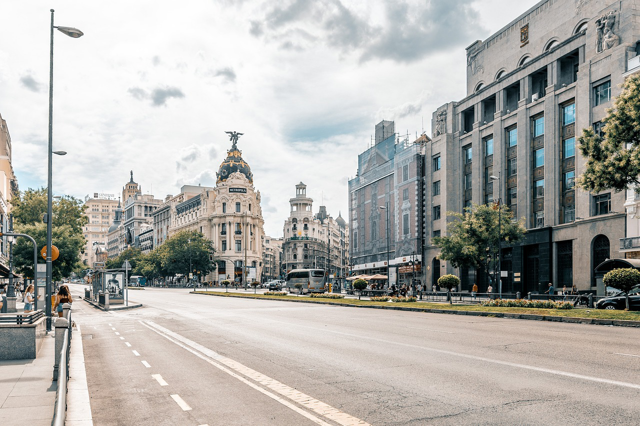

In [4]:
image

In [6]:
# Preprocess the inputs
text_prompt = processor.apply_chat_template(conversation, add_generation_prompt=True)
# Excepted output: '<|im_start|>system\nYou are a helpful assistant.<|im_end|>\n<|im_start|>user\n<|vision_start|><|image_pad|><|vision_end|>Describe this image.<|im_end|>\n<|im_start|>assistant\n'

inputs = processor(
    text=[text_prompt], images=[image], padding=True, return_tensors="pt"
)
#inputs = inputs.to("cuda")

# Inference: Generation of the output
output_ids = model.generate(**inputs, max_new_tokens=128)
generated_ids = [
    output_ids[len(input_ids) :]
    for input_ids, output_ids in zip(inputs.input_ids, output_ids)
]
output_text = processor.batch_decode(
    generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True
)
print(output_text)

['La imagen muestra una avenida en un centro urbano, con edificios de estilo arquitectónico moderno y clásico. En el centro de la imagen, se puede observar una estatua de una figura en una torre, lo que podría ser un monumento o un símbolo de la ciudad. La avenida está llena de vehículos, incluyendo coches y un autobús, y tiene un aspecto tranquilo y ordenado. En el fondo, se pueden ver árboles y edificios más altos, lo que indica una ciudad con una gran cantidad de']


In [7]:
output_text

['La imagen muestra una avenida en un centro urbano, con edificios de estilo arquitectónico moderno y clásico. En el centro de la imagen, se puede observar una estatua de una figura en una torre, lo que podría ser un monumento o un símbolo de la ciudad. La avenida está llena de vehículos, incluyendo coches y un autobús, y tiene un aspecto tranquilo y ordenado. En el fondo, se pueden ver árboles y edificios más altos, lo que indica una ciudad con una gran cantidad de']